In [1]:
# Data anaysis
import pandas as pd
import numpy as np

# Imbalanced dataset handling by resampling
from collections import Counter
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# Plotting and Correlation Maths
import seaborn as sns
import scipy as sci

# Simple model development
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score

# Plotting
import matplotlib.pyplot as plt
import plotly as px

# Pathing (maybe should use PATH in the future?)
import os

In [2]:
# get data
data = pd.read_csv('../data/processed/cleaned_data_survive.csv')
data

,date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,2018-01-07,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,...,0,0,0,1,0,0,0,0,0,0
1,2018-01-09,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,...,0,0,0,1,0,0,0,0,0,0
2,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
3,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
4,2018-01-14,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,2024-04-08,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,...,0,0,0,0,1,0,0,0,0,0
3482,2024-04-10,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,...,0,0,0,0,1,0,0,0,0,0
3483,2024-04-12,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,...,0,0,0,0,1,0,0,0,0,0
3484,2024-04-13,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,...,0,0,0,0,1,0,0,0,0,0


In [3]:
data['survive'].value_counts()

survive
1.0    2942
0.0     544
Name: count, dtype: int64

In [4]:
# I kept the data in the .csv so that we could use it if we needed it
#  For things like the Year
data = data.drop('date', axis=1)
data

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,8.33,...,0,0,0,0,1,0,0,0,0,0
3482,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,62.50,...,0,0,0,0,1,0,0,0,0,0
3483,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3484,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0


In [5]:
data = data.drop('cloudcover', axis=1)

In [6]:
# Split the inputs and targets

target = data['survive'].copy()
inputs = data.drop('survive', axis=1).copy()

In [7]:
# # Checking to see if target balancing is an issue...

# # Assuming df is your dataframe and the last column is the target column
# target_column = 'survive'

# # Separate the dataframe into two dataframes: one for 1s and one for 0s
# df_ones = data[data[target_column] == 1]
# df_zeros = data[data[target_column] == 0]

# # Determine the smaller number of rows between the two dataframes
# min_length = min(len(df_ones), len(df_zeros))

# # Sample the same number of rows from both dataframes
# df_ones_sampled = df_ones.sample(n=min_length, random_state=42)
# df_zeros_sampled = df_zeros.sample(n=min_length, random_state=42)

# # Concatenate the sampled dataframes
# balanced_df = pd.concat([df_ones_sampled, df_zeros_sampled])

# # Optionally, shuffle the concatenated dataframe
# balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# # Display the balanced dataframe
# balanced_df['survive']

# target = balanced_df['survive'].copy()
# inputs = balanced_df.drop('survive', axis=1).copy()

In [8]:
inputs

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,26.2,-4.2,10.1,18.1,-16.6,0.6,-3.8,57.2,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
1,35.8,28.0,32.5,34.7,24.1,26.8,26.6,78.9,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
2,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
3,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
4,15.3,2.5,9.2,14.6,-6.0,3.5,0.5,68.0,0.000,0.00,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,73.0,49.3,60.1,73.0,47.3,60.0,37.1,42.8,0.006,8.33,...,0,0,0,0,1,0,0,0,0,0
3482,65.1,57.1,60.6,65.1,57.1,60.6,54.5,80.9,0.179,62.50,...,0,0,0,0,1,0,0,0,0,0
3483,59.4,46.8,50.8,59.4,39.8,46.5,46.3,84.5,0.266,83.33,...,0,0,0,0,1,0,0,0,0,0
3484,59.2,44.5,51.1,59.2,37.4,47.9,33.0,51.5,0.019,12.50,...,0,0,0,0,1,0,0,0,0,0


In [9]:
# Split the data
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(inputs, target, test_size=0.2, random_state=42)


In [10]:
X_train.shape, X_test.shape


((2788, 25), (698, 25))

In [11]:
y_train.shape, y_test.shape

((2788,), (698,))

# Compute the SVD

Variance cutoff can be done around 15-17 features.  The plot shows the intersection at 95% variance and 16 S values.

This will allow us to drop around 10 features and still have reasonable outputs from the model.

In [12]:
# This will center and scale the dataset for PCA
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
# Remake a DF so we can see the described data to ensure the scaler worked
scaled_X_train_df = pd.DataFrame(scaled_X_train, columns=inputs.columns)
scaled_X_train_df

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,-1.570041,-0.974444,-1.288600,-1.386960,-0.928981,-1.199572,-0.763264,1.500999,-0.374698,-0.132836,...,-0.046441,-0.046441,-0.032821,-0.788589,-0.934022,-0.062937,-0.032821,2.940588,-0.042387,-0.189858
1,-0.945304,-0.992992,-1.246672,-1.099880,-0.923904,-1.168948,-0.809621,1.118328,0.427634,1.212549,...,-0.046441,-0.046441,-0.032821,-0.788589,-0.934022,-0.062937,-0.032821,2.940588,-0.042387,-0.189858
2,-0.900680,-0.523130,-0.719589,-0.971189,-0.502560,-0.719798,-0.415589,0.778979,0.024716,0.827890,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
3,-0.136493,-0.102728,-0.138598,-0.075303,-0.213203,-0.097113,-0.212778,-0.376253,1.152886,1.212549,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
4,-0.694294,-1.326841,-1.019068,-0.570268,-0.913752,-0.852501,-1.406463,-1.379861,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2783,-0.493486,-1.098092,-0.773495,-0.392080,-1.091427,-0.699382,-0.641578,0.201363,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
2784,-1.592353,-1.122822,-1.366464,-1.372111,-1.050815,-1.276132,-0.884950,1.269952,0.021213,0.827890,...,-0.046441,-0.046441,-0.032821,-0.788589,-0.934022,-0.062937,-0.032821,2.940588,-0.042387,-0.189858
2785,-0.627358,-1.073363,-0.869328,-0.510872,-0.837605,-0.745318,-1.024020,-0.657841,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
2786,1.090668,1.183209,1.185101,1.003720,1.147282,1.122738,1.009879,-0.217409,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858


In [13]:
# Check for centering (mean = 0) and standardization
scaled_X_train_df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
count,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,...,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03,2.788000e+03
mean,3.211205e-16,2.140803e-16,-2.599547e-16,-2.191775e-16,1.325259e-16,1.197830e-16,2.038860e-17,5.148122e-16,1.076773e-16,-2.580432e-17,...,1.401716e-17,1.274288e-17,1.083144e-17,5.415722e-17,-1.656574e-17,-2.070717e-17,8.282869e-18,-1.529145e-17,-1.019430e-17,8.920013e-18
std,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,...,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00,1.000179e+00
min,-2.858561e+00,-3.132098e+00,-3.019591e+00,-2.921351e+00,-3.396130e+00,-3.327930e+00,-2.913055e+00,-3.119929e+00,-4.342595e-01,-7.093633e-01,...,-4.644052e-02,-4.644052e-02,-3.282071e-02,-7.885894e-01,-9.340223e-01,-6.293734e-02,-3.282071e-02,-3.400680e-01,-4.238658e-02,-1.898581e-01
25%,-8.337440e-01,-8.631615e-01,-8.513595e-01,-8.387861e-01,-8.693327e-01,-8.576054e-01,-8.327990e-01,-6.722815e-01,-4.342595e-01,-7.093633e-01,...,-4.644052e-02,-4.644052e-02,-3.282071e-02,-7.885894e-01,-9.340223e-01,-6.293734e-02,-3.282071e-02,-3.400680e-01,-4.238658e-02,-1.898581e-01
50%,1.702973e-01,3.946705e-02,6.504763e-02,1.969278e-01,5.584810e-02,1.453260e-01,3.059408e-02,1.002800e-01,-4.202450e-01,-5.170337e-01,...,-4.644052e-02,-4.644052e-02,-3.282071e-02,-7.885894e-01,-9.340223e-01,-6.293734e-02,-3.282071e-02,-3.400680e-01,-4.238658e-02,-1.898581e-01
75%,8.787042e-01,9.297308e-01,9.155693e-01,8.255331e-01,9.391483e-01,8.930587e-01,9.229601e-01,7.500980e-01,-6.988165e-02,4.436921e-01,...,-4.644052e-02,-4.644052e-02,-3.282071e-02,1.268087e+00,1.070638e+00,-6.293734e-02,-3.282071e-02,-3.400680e-01,-4.238658e-02,-1.898581e-01
max,1.732139e+00,1.807630e+00,1.742133e+00,1.924355e+00,1.660003e+00,1.796463e+00,1.815326e+00,2.165257e+00,1.330699e+01,3.902858e+00,...,2.153292e+01,2.153292e+01,3.046856e+01,1.268087e+00,1.070638e+00,1.588882e+01,3.046856e+01,2.940588e+00,2.359237e+01,5.267093e+00


In [14]:
scaled_X_test = scaler.transform(X_test)
scaled_X_test_df = pd.DataFrame(scaled_X_test, columns=scaled_X_train_df.columns)
scaled_X_test_df

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
0,0.549602,1.041014,0.753850,0.533504,1.030524,0.755251,0.928755,0.562373,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
1,1.319367,0.973008,1.316872,1.201706,0.974683,1.235025,0.922960,-0.852786,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
2,0.889860,1.251215,1.017392,0.835432,1.203123,0.979826,1.247457,0.822300,-0.423749,-0.517034,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
3,0.599804,1.109020,0.867653,0.578051,1.086365,0.852227,1.137360,0.937823,-0.315136,0.251362,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
4,-0.733340,-0.869344,-0.785474,-0.723707,-0.832529,-0.740214,-0.838594,-0.383473,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,1.268087,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693,0.845236,1.350133,1.119215,0.795835,1.284346,1.066594,1.073619,-0.036904,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
694,1.090668,0.305310,0.580152,1.048267,0.426428,0.612340,0.650615,0.324106,1.257995,0.443692,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
695,1.046044,1.517058,1.262966,1.201706,1.421410,1.224817,1.548775,1.053346,2.431713,1.404418,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
696,-0.097447,-0.702419,-0.402140,-0.040655,-0.776688,-0.398248,-0.942896,-1.589247,-0.255574,-0.325165,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858


In [15]:
scaled_X_test_df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipcover,...,preciptype_freezingrain,"preciptype_freezingrain,snow","preciptype_freezingrain,snow,ice",preciptype_none,preciptype_rain,"preciptype_rain,freezingrain","preciptype_rain,freezingrain,snow","preciptype_rain,snow","preciptype_rain,snow,ice",preciptype_snow
count,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,...,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000,698.000000
mean,0.109067,0.124373,0.120619,0.104544,0.125900,0.119887,0.121531,0.032143,0.073306,0.024102,...,0.015391,0.046307,0.010878,-0.090262,0.105644,-0.040084,0.010878,-0.015762,-0.008526,-0.025680
std,0.977424,0.989862,0.983946,0.974524,0.987718,0.980632,0.989505,1.001878,1.183542,0.996545,...,1.154288,1.412692,1.154494,0.974645,1.002353,0.603783,1.154494,0.979866,0.894589,0.932846
min,-2.858561,-3.169192,-2.863862,-2.762962,-3.715945,-3.006380,-2.721834,-3.062168,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,-0.788589,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
25%,-0.713817,-0.711693,-0.704615,-0.595016,-0.723385,-0.693002,-0.638680,-0.639791,-0.434260,-0.709363,...,-0.046441,-0.046441,-0.032821,-0.788589,-0.934022,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
50%,0.376684,0.274398,0.328590,0.380065,0.401046,0.390317,0.210226,0.093060,-0.406230,-0.517034,...,-0.046441,-0.046441,-0.032821,-0.788589,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
75%,0.940062,0.997737,0.981455,0.879979,0.994989,0.949202,1.009879,0.820495,0.052746,0.443692,...,-0.046441,-0.046441,-0.032821,1.268087,1.070638,-0.062937,-0.032821,-0.340068,-0.042387,-0.189858
max,1.676359,1.646888,1.700206,1.840211,1.528015,1.689279,1.600927,2.129156,13.306991,3.902858,...,21.532921,21.532921,30.468563,1.268087,1.070638,15.888818,30.468563,2.940588,23.592372,5.267093


In [16]:
# Change the number of singular value components to see how much variance you'll be keeping
#  Max is 26; 15 gives us just under 95%.
n_comps = 9

# Create a PCA class and fit the model
pca = PCA(n_components=n_comps, svd_solver='full')
pca.fit(scaled_X_train)
# Transform via the PCA
scaled_X_train_pca = pca.transform(scaled_X_train)
scaled_X_test_pca = pca.transform(scaled_X_test)

In [17]:
scaled_X_train_pca.shape

(2788, 9)

In [18]:
sum(pca.explained_variance_ratio_)

0.7681558210701357

In [19]:
ratios = pca.explained_variance_ratio_
ratios

array([0.3205589 , 0.13383186, 0.05534014, 0.0509234 , 0.04563604,
       0.04090959, 0.04055594, 0.04029548, 0.04010446])

In [20]:
r_values = np.cumsum(ratios**2) / sum(ratios**2)
print(r_values)

[0.76140834 0.89412362 0.91681613 0.93603097 0.95146282 0.96386369
 0.97605108 0.98808244 1.        ]


<function matplotlib.pyplot.show(close=None, block=None)>

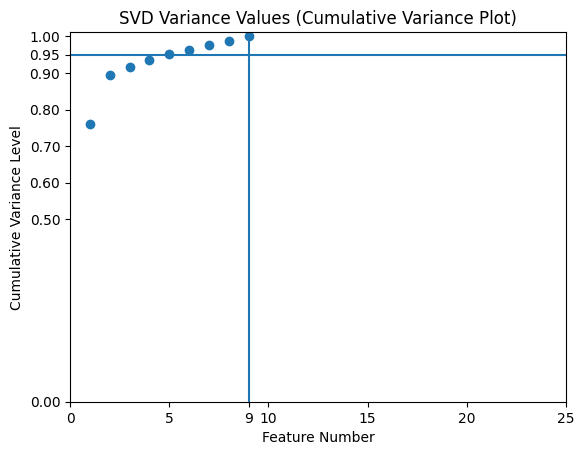

In [21]:
# Create plot; This will only make sense when n_comps = 26!
fig, ax = plt.subplots()
plt.scatter(range(1,len(r_values)+1),r_values)
plt.axhline(0.95)
plt.axvline(9)
plt.xlabel('Feature Number')
plt.ylabel('Cumulative Variance Level')
plt.title('SVD Variance Values (Cumulative Variance Plot)')

xt = [0, 5, 9, 10, 15, 20, 25]
yt = [0,  0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 1.0]
plt.xticks(ticks=xt)
plt.yticks(ticks=yt)

plt.show

# Time to Create a Model

In [22]:
# # Split the data
# X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(inputs_pca, target, test_size=0.2, random_state=42)
# X_train.shape, X_test.shape
# y_train.shape, y_test.shape


In [23]:
scaled_X_train_pca.shape, scaled_X_test_pca.shape

((2788, 9), (698, 9))

In [24]:
y_train.shape, y_test.shape

((2788,), (698,))

In [25]:
#TODO: Either one-hot encode the 'survive' feature or leave it... might depend on the model built



# Logistic Regression Model

In [26]:
# Build your model

# Logistic Regression Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression.fit
log_res = LogisticRegression(class_weight='balanced')
log_res.fit(scaled_X_train_pca, y_train)
log_preds = log_res.predict(scaled_X_test_pca) # Will give predictions for your own analysis
log_res_score = log_res.score(scaled_X_test_pca, y_test)  # Will give mean accuracy on the test data and labels
print(log_res_score)

0.5257879656160458


In [27]:
len(log_preds)

698

In [28]:
log_preds

array([0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1.,
       0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1.,
       0., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0.,
       0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0.,
       0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0.,
       1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1.,
       1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 1.

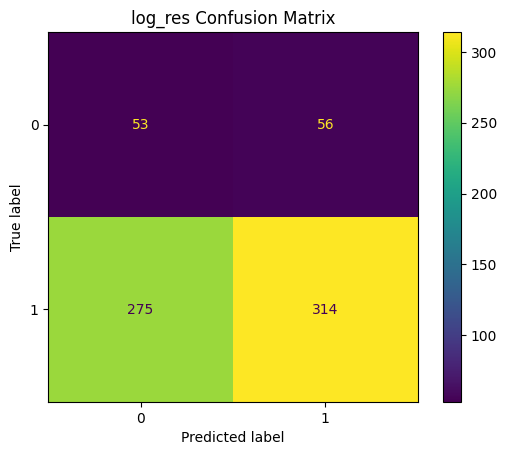

In [29]:
cm = sk.metrics.confusion_matrix(y_test, log_preds)
disp = sk.metrics.ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('log_res Confusion Matrix')
plt.show()

While the log_res looks ok with an accuracy of 0.84, the predictions all come out to 1, which is everyone surviving... I'm certain on further analysis (F1 score, confusion matrix) this'll show up as poor results.

# Random Forest Model

In [30]:

# Random Forest Classifier Setup via sklearn:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
rf = RandomForestClassifier(n_estimators=100, criterion='entropy', class_weight='balanced') # could use 'gini'
rf.fit(scaled_X_train_pca, y_train)
rf_preds = rf.predict(scaled_X_test_pca) # Will give predictions for your own analysis
rf_score = rf.score(scaled_X_test_pca, y_test)  # Will give mean accuracy on the test data and labels
print(rf_score)


0.7392550143266475


In [31]:
np.unique(rf_preds)
rf_preds

array([0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1.,
       1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 1., 1., 1.

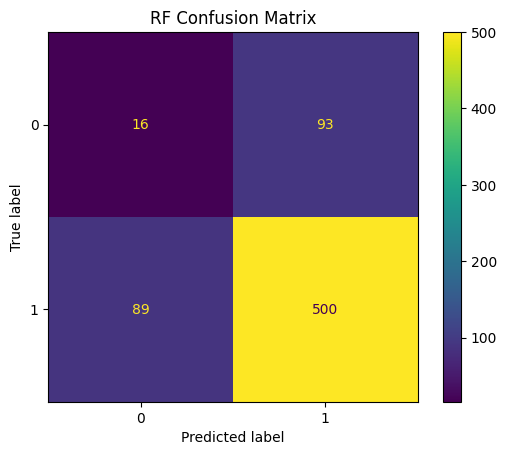

In [32]:
cm = sk.metrics.confusion_matrix(y_test, rf_preds)
disp = sk.metrics.ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('RF Confusion Matrix')
plt.show()

In [33]:
# TODO:
# I can't get my old code to display a decision tree to work...


estimator = rf.estimators_[25]
tree_data = tree.export_graphviz(estimator, out_file='Tree.dot')
#Save the tree out to a pdf file


The RF did a slightly better job, it at least has some 0 values in it signifying deaths that happened.  More post-analysis needs to be done.

In [34]:
# Undersample the dataset to balance
nm = NearMiss()
X_nm, y_nm = nm.fit_resample(scaled_X_train_pca, y_train)

print('Dataset after undersample {}'.format(Counter(y_nm)))

Dataset after undersample Counter({0.0: 435, 1.0: 435})


In [35]:
# Oversample the dataset to balance
os =  RandomOverSampler()
X_os, y_os = os.fit_resample(scaled_X_train_pca, y_train)

print('Dataset after oversample {}'.format(Counter(y_os)))

Dataset after oversample Counter({1.0: 2353, 0.0: 2353})


In [36]:
# SMOTE oversample to balance the dataset
sm = SMOTE(random_state=10)
X_sm, y_sm = sm.fit_resample(scaled_X_train_pca, y_train)

print('Dataset after SMOTE oversample {}'.format(Counter(y_sm)))

Dataset after SMOTE oversample Counter({1.0: 2353, 0.0: 2353})


# Nerual Network Model

In [37]:
# Neural Network Setup via sklearn: (if you wanted to toss this you could use TensorFlow or PyTorch.  doesn't matter to me)
# https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
nn = MLPClassifier(hidden_layer_sizes=(100, 100, 100), activation='relu', solver='adam', max_iter=1000)

# With undersampled data
nn.fit(X_nm, y_nm)
nn_preds = nn.predict(scaled_X_test_pca) # Will give predictions for your own analysis
accuracy = accuracy_score(y_test, nn_preds)
# Will give mean accuracy on the test data and labels
print(accuracy)

0.32664756446991405


In [38]:
# With oversampled data
nn.fit(X_os, y_os)
nn_preds = nn.predict(scaled_X_test_pca) # Will give predictions for your own analysis
accuracy = accuracy_score(y_test, nn_preds)
print(accuracy)

0.6475644699140402


In [39]:
# With SMOTE oversampled data
nn.fit(X_sm, y_sm)
nn_preds = nn.predict(scaled_X_test_pca) # Will give predictions for your own analysis
accuracy = accuracy_score(y_test, nn_preds)
print(accuracy)

0.663323782234957


In [40]:
nn_preds

array([0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0.,
       1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1.,
       0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1.,
       1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 1.

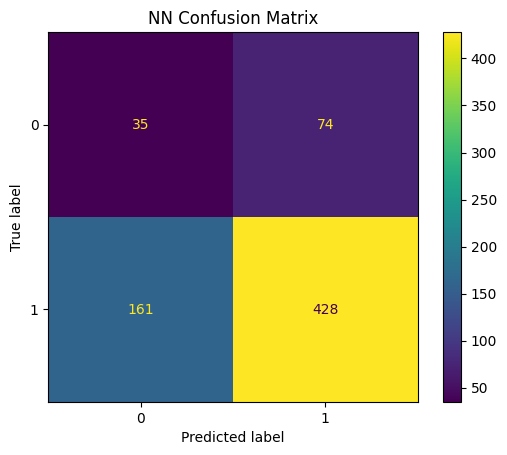

In [41]:
cm = sk.metrics.confusion_matrix(y_test, nn_preds)
disp = sk.metrics.ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('NN Confusion Matrix')
plt.show()

In [42]:
len(nn.loss_curve_)

196

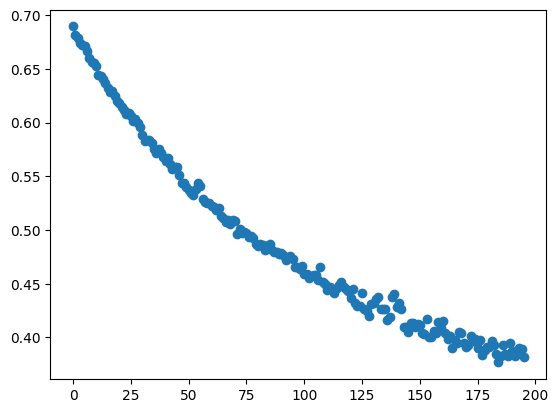

In [44]:
plt.scatter(range(0, 196), nn.loss_curve_)